# MACE in Practice II

In this tutorial, you will learn how to improve MLIP models by using iterative training and active learning. We illustrate these training workflows on MACE, but they are broadly applicable to all MLIPs. We will also showcase the state-of-the-art [foundational models](https://matbench-discovery.materialsproject.org/) - the latest development in the field of MLIPs. These models are trained on massive training sets of [inorganic](https://doi.org/10.48550/arXiv.2401.00096) and [organic](https://doi.org/10.48550/arXiv.2312.15211) databases and show a great deal of `out-of-the-box` MD stability in an extensive variety of [applications](https://doi.org/10.48550/arXiv.2401.00096). We will discuss [fine-tunning](https://doi.org/10.48550/arXiv.2405.20217) which is an actively-researched technique to tweak these foundational models to new systems (out of training) and/or new levels of reference theory.
This notebook was made by Ioan Magdău and Ilyes Batatia and Will Baldwin.

## Learning Objectives for today:

1. **Iterative Training: improving stability and accuracy**
2. **Active learning: committee models**
3. **Foundational models and fine-tuning**

In [11]:
import sys
from pathlib import Path

if "google.colab" in sys.modules:
    !pip install --upgrade pip
    !git clone https://github.com/imagdau/Tutorials.git
    !pip install mace-torch nglview ipywidgets rdkit x3dase
    !pip install git+https://github.com/imagdau/aseMolec@3b1667abd2e4b061aa9f2e910634d38e17fe4779
    !pip install -U numpy==2.0
    !pip install cuequivariance cuequivariance-torch cuequivariance-ops-torch-cu12
    !pip install ase_ga

tutorial_dir = Path.cwd()
if not (tutorial_dir / "data").is_dir():
    tutorial_dir /= "Tutorials"
%cd {tutorial_dir}

Cloning into 'Tutorials'...
remote: Enumerating objects: 350, done.
remote: Counting objects: 100% (120/120), done.
remote: Compressing objects: 100% (85/85), done.
remote: Total 350 (delta 58), reused 93 (delta 35), pack-reused 230 (from 1)
Receiving objects: 100% (350/350), 34.19 MiB | 8.49 MiB/s, done.
Resolving deltas: 100% (166/166), done.
  Using cached numpy-1.26.4-cp311-cp311-macosx_11_0_arm64.whl.metadata (114 kB)
Using cached numpy-1.26.4-cp311-cp311-macosx_11_0_arm64.whl (14.0 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.0
    Uninstalling numpy-2.0.0:
      Successfully uninstalled numpy-2.0.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pyannote-audio 3.3.2 requires torchaudio>=2.2.0, which is not installed.
llava-mlmi4 0.1.0 requires torchvision>=0.12.0, which is not installed.
fairchem-core 2.3.0 requires cluste

## 1. Iterative Training

### 1.1 MD with a smaller MACE model

The model we trained in our previous tutorial was already stable in MD and quite accurate with little training. This is both because MACE models are smooth and very accurate but also because the task of simulating a single molecule for a few picoseconds is not all that difficult. In general, in real research applications, achieving MD stability and accuracy is not always straightforward from the get-go. Models can be improved through iterative training and active learning which expands the training data to fix errors on the model's potential energy surface.

**To illustrate these concepts in practice, let's first train a less accurate MACE by reducing a lot the model size and amount of training data: we will make a model with just 20 training configurations. Note that a larger model would probably work out of the box for this example.**

In [12]:
from ase.io import read, write
db = read('data/solvent_xtb.xyz', ':')
write('data/solvent_xtb_train_50.xyz', db[:53]) #first 50 configs plus the 3 E0s, we'll use only 20 of them for training!

Let's make an input config.

In [13]:
%%writefile config/config-03.yml

model: "MACE"
num_channels: 32
max_L: 0
r_max: 4.0
name: "mace02_com1"
model_dir: "MACE_models"
log_dir: "MACE_models"
checkpoints_dir: "MACE_models"
results_dir: "MACE_models"
train_file: "data/solvent_xtb_train_20.xyz"
valid_file: "data/solvent_xtb_train_50.xyz"
test_file: "data/solvent_xtb_test.xyz"
energy_key: "energy_xtb"
forces_key: "forces_xtb"
device: cpu
batch_size: 5
max_num_epochs: 300
swa: True
seed: 123
enable_cueq: False


Writing config/config-03.yml


In [14]:
import warnings
warnings.filterwarnings("ignore")
from mace.cli.run_train import main as mace_run_train_main
import sys
import logging

def train_mace(config_file_path):
    logging.getLogger().handlers.clear()
    sys.argv = ["program", "--config", config_file_path]
    mace_run_train_main()

In [15]:
train_mace("config/config-03.yml")

2026-07-13 00:10:29.890 INFO: ===========VERIFYING SETTINGS===========
2026-07-13 00:10:29.890 INFO: MACE version: 0.3.16
2026-07-13 00:10:29.891 INFO: Using CPU
2026-07-13 00:10:29.914 INFO: ===========LOADING INPUT DATA===========
2026-07-13 00:10:29.914 INFO: Using heads: ['Default']
2026-07-13 00:10:29.915 INFO: Using the key specifications to parse data:
2026-07-13 00:10:29.915 INFO: Default: KeySpecification(info_keys={'energy': 'energy_xtb', 'stress': 'REF_stress', 'virials': 'REF_virials', 'dipole': 'dipole', 'head': 'head', 'elec_temp': 'elec_temp', 'total_charge': 'total_charge', 'polarizability': 'polarizability', 'total_spin': 'total_spin'}, arrays_keys={'forces': 'forces_xtb', 'charges': 'REF_charges'})
2026-07-13 00:10:29.915 INFO: =============    Processing head Default     ===========
2026-07-13 00:10:29.923 INFO: Using isolated atom energies from training file
2026-07-13 00:10:29.924 INFO: Training set 1/1 [energy: 18, stress: 0, virials: 0, dipole components: 0, head

In [16]:
#remove checkpoints since they may cause errors on retraining a model with the same name but a different architecture
import glob
import os
for file in glob.glob("MACE_models/*.pt"):
    os.remove(file)

Notice, we are getting substantially larger errors than before. Now, let's run some dynamics:

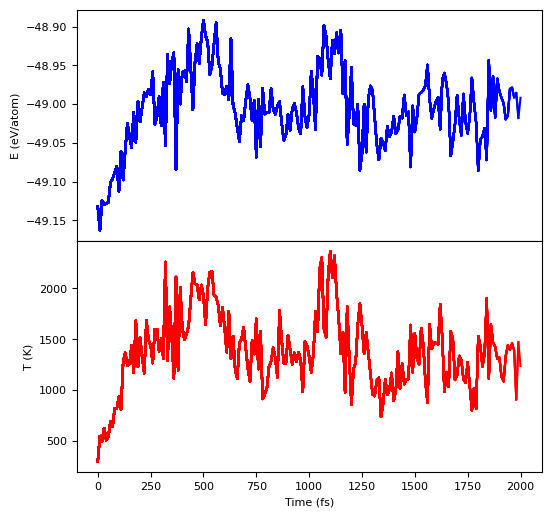

MD finished in 0.61 minutes!


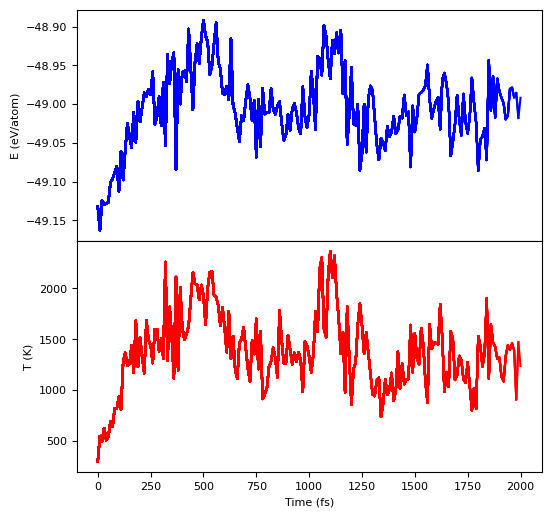

In [23]:
from ase.io import read, write
from ase import units
from ase.md.langevin import Langevin
from ase.md.velocitydistribution import Stationary, ZeroRotation, MaxwellBoltzmannDistribution
from aseMolec import extAtoms as ea

import os
import time
import numpy as np
import pylab as pl
from IPython import display
np.random.seed(701) #just making sure the MD failure is reproducible

def simpleMD(init_conf, temp, calc, fname, s, T):
    init_conf.set_calculator(calc)

    #initialize the temperature

    MaxwellBoltzmannDistribution(init_conf, temperature_K=300) #initialize temperature at 300
    Stationary(init_conf)
    ZeroRotation(init_conf)

    dyn = Langevin(init_conf, 1.0*units.fs, temperature_K=temp, friction=0.1) #drive system to desired temperature

    %matplotlib inline

    time_fs = []
    temperature = []
    energies = []

    #remove previously stored trajectory with the same name
    os.system('rm -rfv '+fname)

    fig, ax = pl.subplots(2, 1, figsize=(6,6), sharex='all', gridspec_kw={'hspace': 0, 'wspace': 0})

    def write_frame():
            dyn.atoms.info['energy_mace'] = dyn.atoms.get_potential_energy()
            dyn.atoms.arrays['force_mace'] = dyn.atoms.calc.get_forces()
            dyn.atoms.write(fname, append=True)
            time_fs.append(dyn.get_time()/units.fs)
            temperature.append(dyn.atoms.get_temperature())
            energies.append(dyn.atoms.get_potential_energy()/len(dyn.atoms))

            ax[0].plot(np.array(time_fs), np.array(energies), color="b")
            ax[0].set_ylabel('E (eV/atom)')

            # plot the temperature of the system as subplots
            ax[1].plot(np.array(time_fs), temperature, color="r")
            ax[1].set_ylabel('T (K)')
            ax[1].set_xlabel('Time (fs)')

            display.clear_output(wait=True)
            display.display(pl.gcf())
            time.sleep(0.01)

    dyn.attach(write_frame, interval=s)
    t0 = time.time()
    dyn.run(T)
    t1 = time.time()
    print("MD finished in {0:.2f} minutes!".format((t1-t0)/60))

#let us start with a single molecule
init_conf = ea.sel_by_info_val(read('data/solvent_molecs.xyz',':'), 'Nmols', 1)[0].copy()

#we can use MACE as a calculator in ASE!
from mace.calculators import MACECalculator
mace_calc = MACECalculator(model_paths=['MACE_models/mace02_com1_run-123_stagetwo.model'], device='cpu', enable_cueq=False)

simpleMD(init_conf, temp=1200, calc=mace_calc, fname='moldyn/mace02_md.xyz', s=10, T=2000)

Depending on the random seed for the MD, you may see different things. At first sight, the energy against time doesn't look too bad, although the long time scale wandering of the energy is a little weird. Lets look at the trajectory. You might even see an explosion.

In [24]:
from ase.io import read, write
from x3dase.visualize import view_x3d_n

traj = read('moldyn/mace02_md.xyz', ':')
view_x3d_n(traj)

If you go to the end of the trajectory, you should find that the bond angles are actually very strange - it looks unphsyical.

### 1.2 Identify the problem and expand training

Something doesn't look right with the hydrogen atoms. Let's re-evaluate the first 100 steps from the trajectory on the reference XTB potential energy surface and then plot it against MACE energy.

In [25]:
from ase.io import read, write
from tqdm import tqdm
try:
    from xtb.ase.calculator import XTB
except ImportError:
    from tblite.ase import TBLite as XTB
xtb_calc = XTB(method="GFN2-xTB")

#compute true reference XTB values
print("Evaluating MACE configurations with XTB")
traj = read('moldyn/mace02_md.xyz', ':')
for at in tqdm(traj[:100]):
    at.calc = None
    at.calc = xtb_calc
    at.info['energy_xtb'] = at.get_potential_energy()
    at.arrays['forces_xtb'] = at.get_forces()
    at.calc = None

write('data/mace02_md_100_xtb.xyz', traj[:100]) #save full result

ModuleNotFoundError: No module named 'xtb'

Text(0, 0.5, 'Total Energy per Atom (eV)')

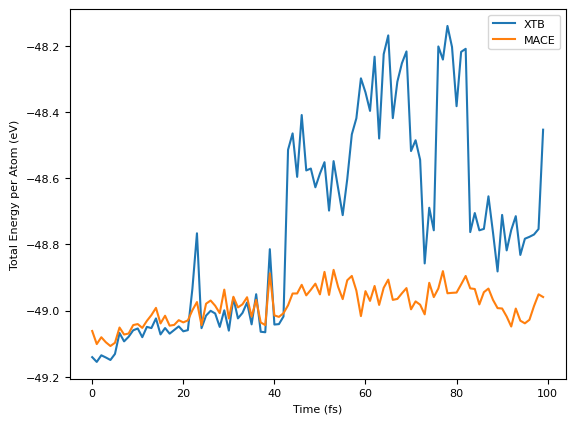

In [26]:
import numpy as np
from aseMolec import extAtoms as ea
from matplotlib import pyplot as plt

traj = read('data/mace02_md_100_xtb.xyz', ':')
plt.plot(np.arange(len(traj)), ea.get_prop(traj, 'info', 'energy_xtb', peratom=True), label='XTB')
plt.plot(np.arange(len(traj)), ea.get_prop(traj, 'info', 'energy_mace', peratom=True), label='MACE')
plt.legend()
plt.xlabel('Time (fs)')
plt.ylabel('Total Energy per Atom (eV)')

Indeed, at around frame 45 the XTB energy diverges, because MACE finds an unphysical config. With older potentials, at this point the MD would explode, but because MACE is much smoother the simulation keeps going, albeit generating the wrong dynamics. Let's take three of these failed configs, add them back to the training set and refit a new model. This is called iterative training:
![alt text](https://github.com/imagdau/Tutorials/blob/main/figures/iterative_training.png?raw=1)

In [27]:
db = read('data/solvent_xtb_train_20.xyz', ':')
db += traj[40:100:5] #add failed configs to the training set
write('data/solvent_xtb_train_23_gen1.xyz', db)

A good exercise is to try to pick the configs that have the largest error on forces and energies. Try coding it yourself.

### 1.3 Train a new MACE model and run MD again

In [ ]:
%%writefile config/config-04.yml

model: "MACE"
num_channels: 32
max_L: 0
r_max: 4.0
name: "mace02_com1_gen1"
model_dir: "MACE_models"
log_dir: "MACE_models"
checkpoints_dir: "MACE_models"
results_dir: "MACE_models"
train_file: "data/solvent_xtb_train_23_gen1.xyz"
valid_file: "data/solvent_xtb_train_50.xyz"
test_file: "data/solvent_xtb_test.xyz"
energy_key: "energy_xtb"
forces_key: "forces_xtb"
device: cpu
batch_size: 10
max_num_epochs: 500
swa: True
seed: 123


Writing config/config-04.yml


In [29]:
train_mace("config/config-04.yml")

2026-07-13 00:31:25.295 INFO: ===========VERIFYING SETTINGS===========
2026-07-13 00:31:25.296 INFO: MACE version: 0.3.16


AssertionError: No CUDA device available!

In [ ]:
#remove checkpoints since they may cause errors on retraining a model with the same name but a different architecture
import glob
import os
for file in glob.glob("MACE_models/*.pt"):
    os.remove(file)

For some reason the energy error on the training set is now huge - can you work out why this is?

What does this imply about how we do iterative training?

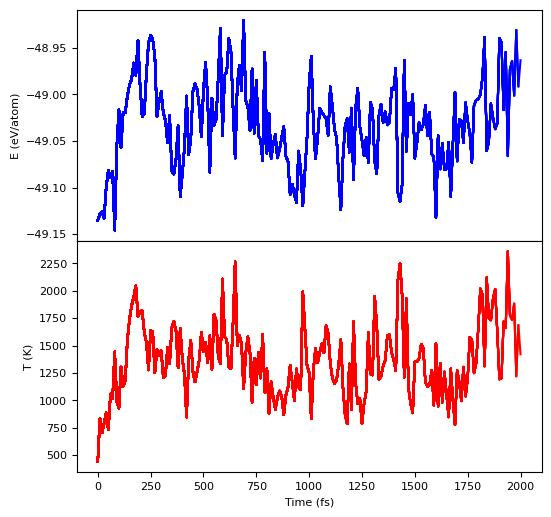

MD finished in 2.07 minutes!


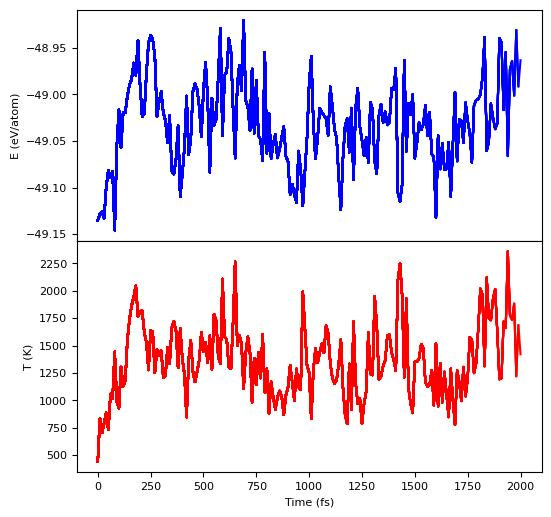

In [ ]:
mace_calc = MACECalculator(model_paths=['MACE_models/mace02_com1_gen1_run-123_stagetwo.model'], device='cuda')
init_conf = ea.sel_by_info_val(read('data/solvent_molecs.xyz',':'), 'Nmols', 1)[0].copy()
simpleMD(init_conf, temp=1200, calc=mace_calc, fname='moldyn/mace02_md_gen1.xyz', s=10, T=2000)

In [ ]:
traj = read('moldyn/mace02_md_gen1.xyz', ':')
view_x3d_n(traj)

Great! The dynamics is already looking better, however its hard to tell if it is really correct. To do this we cuold look at the radial distribution function compared to a ground truth trajectory, but if the ground truth is too expensive its not so easy.

If we have reason to believe the model is wrong, we could continue the iterative process and gradually improve the potential. This is an arduous process, because we need to carefully investigate the trajectories and decide which configs to add back to training. We could instead automate this protocol by predicting errors on the fly and picking configs which are not well predicted: this is called active learning.

## 2. Active Learning with MACE

### 2.1 Preparing a committee of models

We can compute errors by evaluating the reference energy and forces (in our case XTB) and computing the difference to MACE predictions. In real research applications, this can be very expensive to evaluate depending on the reference level of theory. Alternatively, we can estimate errors based on a committee of models. Let's train a committee of MACE models by adding some randomness to the optimization process. We can achieve this by changing the `--seed`. We already have a model, we will fit two more, on the same data:

In [ ]:
%%writefile config/config-05.yml

model: "MACE"
num_channels: 32
max_L: 0
r_max: 4.0
name: "mace02_com2"
model_dir: "MACE_models"
log_dir: "MACE_models"
checkpoints_dir: "MACE_models"
results_dir: "MACE_models"
train_file: "data/solvent_xtb_train_23_gen1.xyz"
valid_file: "data/solvent_xtb_train_50.xyz"
test_file: "data/solvent_xtb_test.xyz"
energy_key: "energy_xtb"
forces_key: "forces_xtb"
device: cuda
batch_size: 10
max_num_epochs: 500
swa: True
seed: 345

Writing config/config-05.yml


In [ ]:
%%writefile config/config-06.yml

model: "MACE"
num_channels: 32
max_L: 0
r_max: 4.0
name: "mace02_com3"
model_dir: "MACE_models"
log_dir: "MACE_models"
checkpoints_dir: "MACE_models"
results_dir: "MACE_models"
train_file: "data/solvent_xtb_train_23_gen1.xyz"
valid_file: "data/solvent_xtb_train_50.xyz"
test_file: "data/solvent_xtb_test.xyz"
energy_key: "energy_xtb"
forces_key: "forces_xtb"
device: cuda
batch_size: 10
max_num_epochs: 500
swa: True
seed: 567

Writing config/config-06.yml


In [ ]:
train_mace("config/config-05.yml")
train_mace("config/config-06.yml")

2026-07-11 15:10:36.937 INFO: ===========VERIFYING SETTINGS===========
2026-07-11 15:10:36.938 INFO: MACE version: 0.3.16
2026-07-11 15:10:36.939 INFO: CUDA version: 12.8, CUDA device: 0
2026-07-11 15:10:36.946 INFO: ===========LOADING INPUT DATA===========
2026-07-11 15:10:36.947 INFO: Using heads: ['Default']
2026-07-11 15:10:36.948 INFO: Using the key specifications to parse data:
2026-07-11 15:10:36.950 INFO: Default: KeySpecification(info_keys={'energy': 'energy_xtb', 'stress': 'REF_stress', 'virials': 'REF_virials', 'dipole': 'dipole', 'head': 'head', 'elec_temp': 'elec_temp', 'total_charge': 'total_charge', 'polarizability': 'polarizability', 'total_spin': 'total_spin'}, arrays_keys={'forces': 'forces_xtb', 'charges': 'REF_charges'})
2026-07-11 15:10:36.951 INFO: =============    Processing head Default     ===========
2026-07-11 15:10:36.980 INFO: Using isolated atom energies from training file
2026-07-11 15:10:36.982 INFO: Training set 1/1 [energy: 30, stress: 0, virials: 0, d

/tmp/ipykernel_1748/344586448.py:8: ResourceWarning: unclosed file <_io.TextIOWrapper name='/content/Tutorials/MACE_models/mace02_com1_gen1_run-123_debug.log' mode='a' encoding='utf-8'>
  logging.getLogger().handlers.clear()
/tmp/ipykernel_1748/344586448.py:8: ResourceWarning: unclosed file <_io.TextIOWrapper name='/content/Tutorials/MACE_models/mace02_com1_gen1_run-123.log' mode='a' encoding='utf-8'>
  logging.getLogger().handlers.clear()
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


2026-07-11 15:10:37.354 INFO: Test set 1/1 [energy: 1000, stress: 0, virials: 0, dipole components: 0, head: 1000, elec_temp: 0, total_charge: 0, polarizability: 0, total_spin: 0, forces: 1000, charges: 0]
2026-07-11 15:10:37.362 INFO: Total Test set [energy: 1000, stress: 0, virials: 0, dipole components: 0, head: 1000, elec_temp: 0, total_charge: 0, polarizability: 0, total_spin: 0, forces: 1000, charges: 0]
2026-07-11 15:10:37.363 INFO: Total number of configurations: train=30, valid=53, tests=[Default_Default: 1000],
2026-07-11 15:10:37.365 INFO: Atomic Numbers used: [np.int64(1), np.int64(6), np.int64(8)]
2026-07-11 15:10:37.367 INFO: Atomic Energies used (z: eV) for head Default: {1: -10.707211383396714, 6: -48.847445262804705, 8: -102.57117256025786}
2026-07-11 15:10:37.368 INFO: Processing datasets for head 'Default'
2026-07-11 15:10:37.400 INFO: Combining 1 list datasets for head 'Default'
2026-07-11 15:10:37.459 INFO: Combining 1 list datasets for head 'Default_valid'
2026-07

/usr/local/lib/python3.12/dist-packages/torch/jit/_script.py:1488: DeprecationWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(
/usr/lib/python3.12/ast.py:407: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  return visitor(node)
/usr/local/lib/python3.12/dist-packages/torch/jit/_script.py:1488: DeprecationWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(
/usr/lib/python3.12/ast.py:407: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  return visitor(node)
/usr/local/lib/python3.12/dist-packages/torch/jit/_s

2026-07-11 15:10:38.678 INFO: ===========OPTIMIZER INFORMATION===========
2026-07-11 15:10:38.679 INFO: Using ADAM as parameter optimizer
2026-07-11 15:10:38.681 INFO: Batch size: 10
2026-07-11 15:10:38.682 INFO: Number of gradient updates: 1500
2026-07-11 15:10:38.683 INFO: Learning rate: 0.01, weight decay: 5e-07
2026-07-11 15:10:38.685 INFO: WeightedEnergyForcesLoss(energy_weight=1.000, forces_weight=100.000)
2026-07-11 15:10:38.688 INFO: === Layer's learning rates ===
2026-07-11 15:10:38.689 INFO: Param group 0: lr = 0.01
2026-07-11 15:10:38.691 INFO: Param group 1: lr = 0.01
2026-07-11 15:10:38.691 INFO: Param group 2: lr = 0.01
2026-07-11 15:10:38.692 INFO: Param group 3: lr = 0.01
2026-07-11 15:10:38.693 INFO: Param group 4: lr = 0.01
2026-07-11 15:10:38.694 INFO: Stage Two (after 375 epochs) with loss function: WeightedEnergyForcesLoss(energy_weight=1000.000, forces_weight=100.000), with energy weight : 1000.0, forces weight : 100.0 and learning rate : 0.001


...

2026-07-11 15:18:58.724 INFO: Compiling model, saving metadata MACE_models/mace02_com3_stagetwo_compiled.model


/usr/local/lib/python3.12/dist-packages/torch/jit/_script.py:1488: DeprecationWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/jit/_trace.py:1145: DeprecationWarning: `torch.jit.trace_method` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(
/usr/lib/python3.12/ast.py:407: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  return visitor(node)


2026-07-11 15:18:59.418 INFO: Computing metrics for training, validation, and test sets
2026-07-11 15:18:59.420 INFO: Skipping evaluation for heads: ['pt_head']
2026-07-11 15:18:59.423 INFO: Evaluating train_Default ...
2026-07-11 15:18:59.600 INFO: Evaluating valid_Default ...
2026-07-11 15:18:59.835 INFO: Error-table on TRAIN and VALID:
+---------------+---------------------+------------------+-------------------+
|  config_type  | RMSE E / meV / atom | RMSE F / meV / A | relative F RMSE % |
+---------------+---------------------+------------------+-------------------+
| train_Default |            7.1      |         88.2     |          3.62     |
| valid_Default |            7.4      |        149.4     |          8.37     |
+---------------+---------------------+------------------+-------------------+
2026-07-11 15:18:59.836 INFO: Evaluating Default_Default ...
2026-07-11 15:19:03.489 INFO: Error-table on TEST:
+-----------------+---------------------+------------------+-------------

/usr/local/lib/python3.12/dist-packages/mace/cli/visualise_train.py:281: MatplotlibDeprecationWarning: Passing label as a length 2 sequence when plotting a single dataset is deprecated in Matplotlib 3.9 and will error in 3.11.  To keep the current behavior, cast the sequence to string before passing.
  main_ax.plot(
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2170: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  result = self._expression.parseString(s)
/usr/local/lib/python3.12/dist-packages/pyparsing/util.py:466: PyparsingDeprecationWarning: 'parseAll' argument is deprecated, use 'parse_all'
  return fn(self, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2178: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  ParserElement.resetCache()
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and schedule

2026-07-11 15:19:11.469 INFO: Done


In [ ]:
#remove checkpoints since they may cause errors on retraining a model with the same name but a different architecture
import glob
import os
for file in glob.glob("MACE_models/*.pt"):
    os.remove(file)

Perfect, we have two new models. Let's start by testing the commitee on the first 100 frames of the first trajectory we generated. The `MACECalculator` can conveniently take a list of calculators as input and will compute separate energies from each calculator.

/usr/local/lib/python3.12/dist-packages/mace/calculators/mace.py:226: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)
/usr/local/lib/python3.12/dist-packages/torch/jit/_serialization.py:176: DeprecationWarning: `torch.jit.load` is deprecated. Please switch to `torch.export`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/jit/_serialization.py:176: DeprecationWarning: `torch.jit.load` is deprecated. Please switch to `torch.export`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/jit/_serialization.py:176: DeprecationWarning: `torch.jit.load` is deprecated. Please switch to `torch.export`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/mace/calculators/mace.py:226: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argum

2026-07-11 15:19:11.871 INFO: Running committee mace with 3 models
2026-07-11 15:19:11.876 INFO: CUDA version: 12.8, CUDA device: 0
2026-07-11 15:19:11.877 INFO: Using head Default out of  ['Default']
2026-07-11 15:19:11.878 WARNING: No dtype selected, switching to float64 to match model dtype.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/torch/jit/_serialization.py:176: DeprecationWarning: `torch.jit.load` is deprecated. Please switch to `torch.export`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/jit/_serialization.py:176: DeprecationWarning: `torch.jit.load` is deprecated. Please switch to `torch.export`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/mace/calculators/mace.py:226: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)
/usr/local/lib/python3.12/dist

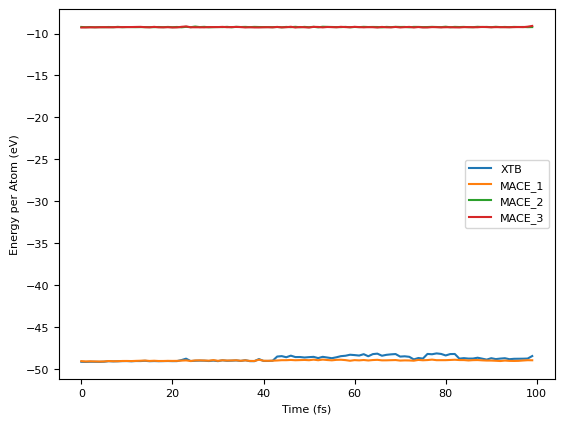

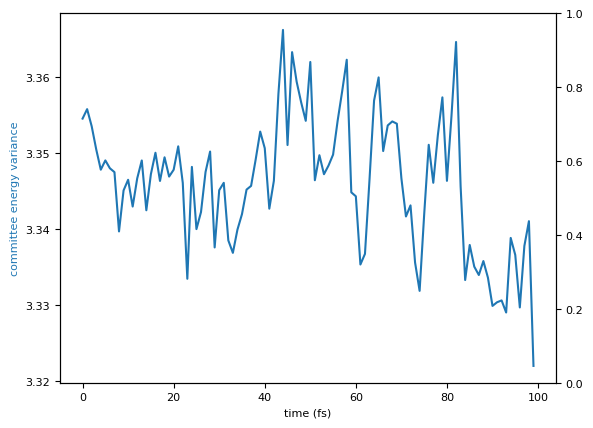

In [ ]:
import numpy as np
from ase.io import read
from aseMolec import extAtoms as ea
from matplotlib import pyplot as plt
from mace.calculators import MACECalculator
from tqdm import tqdm

model_paths = ['MACE_models/mace02_com3_run-567_stagetwo.model',
               'MACE_models/mace02_com2_run-345_stagetwo.model',
               'MACE_models/mace02_com1_gen1_run-123_stagetwo.model']
mace_calcs = MACECalculator(model_paths=model_paths, device='cuda')

traj = read('data/mace02_md_100_xtb.xyz', ':')
for at in tqdm(traj):
    at.calc = mace_calcs
    engs = at.get_potential_energies()
    at.info['energy_mace_1'] = at.info.pop('energy_mace') #rename value obtained with first member of the committee
    at.info['energy_mace_2'] = engs[1]
    at.info['energy_mace_3'] = engs[2]
    at.info['variance'] = np.std(engs)
    at.info['average_mace_energy'] = np.average(engs)
    at.info['true_error'] = np.abs(at.info['average_mace_energy'] - at.info['energy_xtb'])

#Let's check the energies of the MACE committee vs XTB energy
plt.plot(np.arange(len(traj)), ea.get_prop(traj, 'info', 'energy_xtb', peratom=True), label='XTB')
plt.plot(np.arange(len(traj)), ea.get_prop(traj, 'info', 'energy_mace_1', peratom=True), label='MACE_1')
plt.plot(np.arange(len(traj)), ea.get_prop(traj, 'info', 'energy_mace_2', peratom=True), label='MACE_2')
plt.plot(np.arange(len(traj)), ea.get_prop(traj, 'info', 'energy_mace_3', peratom=True), label='MACE_3')
plt.legend()
plt.xlabel('Time (fs)')
plt.ylabel('Energy per Atom (eV)')
plt.show()


#plt.plot(np.arange(len(traj)), ea.get_prop(traj, 'info', 'variance', peratom=True), label='committee variance')
#plt.plot(np.arange(len(traj)), ea.get_prop(traj, 'info', 'true_error', peratom=True), label='error w.r.t XTB')

fig, ax1 = plt.subplots()
ax2 = ax1.twinx()
ax1.plot(np.arange(len(traj)), ea.get_prop(traj, 'info', 'variance', peratom=True), label='committee variance', color='tab:blue')
#ax2.plot(np.arange(len(traj)), ea.get_prop(traj, 'info', 'true_error', peratom=True), label='error w.r.t XTB', color='tab:orange')

ax1.set_xlabel('time (fs)')
ax1.set_ylabel('committee energy variance', color='tab:blue')
#ax2.set_ylabel('error w.r.t XTB', color='tab:orange')

plt.show()

Notice how the variance (disagreement between models) increases around the same config where the true error with respect to XTB diverges. This is good news because it indicates the variance is a good proxy for true error.

Now we can run dynamics with a commitee of models and monitor the variance in the energy prediction. Because XTB is cheap enough we can also compare that variance with the true error. Do they correlate?

### 2.2 Running MD with the MACE committee

In [ ]:
from aseMolec import extAtoms as ea
from ase import units
from ase.md.langevin import Langevin
from ase.md.velocitydistribution import Stationary, ZeroRotation, MaxwellBoltzmannDistribution
from ase.io import read, write

import random
import numpy as np
import time
import pylab as pl
from IPython import display

from mace.calculators import MACECalculator
try:
    from xtb.ase.calculator import XTB
except ImportError:
    from tblite.ase import TBLite as XTB

model_paths = ['MACE_models/mace02_com3_run-567_stagetwo.model',
               'MACE_models/mace02_com2_run-345_stagetwo.model',
               'MACE_models/mace02_com1_gen1_run-123_stagetwo.model']

xtb_calc = XTB(method="GFN2-xTB")
mace_calc = MACECalculator(model_paths=model_paths, device='cpu')

init_conf = ea.sel_by_info_val(read('data/solvent_molecs.xyz',':'), 'Nmols', 1)[0].copy()
init_conf.calc = mace_calc

#initialize the temperature
np.random.seed(701)
MaxwellBoltzmannDistribution(init_conf, temperature_K=300)
Stationary(init_conf)
ZeroRotation(init_conf)

dyn = Langevin(init_conf, 1*units.fs, temperature_K=1200, friction=0.1)

%matplotlib inline

time_fs = []
temperature = []
energies_1 = []
energies_2 = []
energies_3 = []
variances = []
xtb_energies = []
true_errors = []

!rm -rfv moldyn/mace02_md_committee.xyz
fig, ax = pl.subplots(4, 1, figsize=(8,8), sharex='all', gridspec_kw={'hspace': 0, 'wspace': 0})


def write_frame():
        at = dyn.atoms.copy()
        at.calc = xtb_calc
        xtb_energy = at.get_potential_energy()

        dyn.atoms.write('moldyn/mace02_md_committee.xyz', append=True, write_results=False)
        time_fs.append(dyn.get_time()/units.fs)
        temperature.append(dyn.atoms.get_temperature())
        energies_1.append(dyn.atoms.calc.results["energies"][0]/len(dyn.atoms))
        energies_2.append(dyn.atoms.calc.results["energies"][1]/len(dyn.atoms))
        energies_3.append(dyn.atoms.calc.results["energies"][2]/len(dyn.atoms))
        variances.append(dyn.atoms.calc.results["energy_var"]/len(dyn.atoms))
        xtb_energies.append(xtb_energy/len(dyn.atoms))
        true_errors.append(np.var([dyn.atoms.calc.results["energy"],xtb_energy])/len(dyn.atoms))

        # plot the true error
        ax[0].plot(np.array(time_fs), np.array(true_errors), color="black")
        ax[0].set_ylabel(r'$\Delta$ E (eV$^2$/atom)')
        ax[0].legend(['Error w.r.t. XTB'], loc='upper left')

        # plot committee variance
        ax[1].plot(np.array(time_fs), np.array(variances), color="y")
        ax[1].set_ylabel(r'committee variance')
        ax[1].legend(['Estimated Error (committee variances)'], loc='upper left')

        # plot the temperature of the system as subplots
        ax[2].plot(np.array(time_fs), temperature, color="r", label='Temperature')
        ax[2].set_ylabel("T (K)")

        ax[3].plot(np.array(time_fs), energies_1, color="g")
        ax[3].plot(np.array(time_fs), energies_2, color="y")
        ax[3].plot(np.array(time_fs), energies_3, color="olive")
        ax[3].plot(np.array(time_fs), xtb_energies, color="black")
        ax[3].set_ylabel("E (eV/atom)")
        ax[3].set_xlabel('Time (fs)')
        ax[3].legend(['E mace1', 'E mace2', 'E mace3', 'E xtb'], loc='upper left')

        display.clear_output(wait=True)
        display.display(fig)
        time.sleep(0.01)

dyn.attach(write_frame, interval=10)
dyn.run(500)
print("MD finished!")

ModuleNotFoundError: No module named 'xtb'

NOTE: if you get the error `xtb could not evalute the config` that means the dynamics went so crazy and gave such strange configurations, that xtb refused to run! thats to be expected if the model is really bad. Copy some of the code above to have a look at the trajectory if you'd like to see this.

Closely observe the dynamics. Notice how good the committee error is as a proxy for the true error. In this case the true is cheap to compute, but in most practical applications it won't be. Therefore, we will need to rely on the committee error to identy configurations that should be added back to the training set. This is called active learning:

![alt text](https://github.com/imagdau/Tutorials/blob/main/figures/active_learning.png?raw=1)

### Active learning in practice

The way to use active learning to improve the model is as follows:
1. run dynmics, track the uncertainty.
2. if the uncertainty breaches some predeterined value, stop the simulation and peform the ground truth calculation.
3. and the new config to the dataset, and retrain
4. repeat steps 1-3 until the uncertainty never crosses the threshold

This can be done without human supervision - you can write a program which loops this process.

As an exercise at the end of the notebook, try writing an active learing loop to gradually grow the dataset and produce a good model, without ever running XTB dynamics.

## 3 Foundational Models

### 3.1 Molecular Dynamics with MACE-MP-0

Foundation models changed everything. MACE-MP-0 is a model trained on >1 million DFT calcuations, and can run dynamics for the whole periodic table.

Mace provides a simple interface to load a foundational model, which we can use mow. Check the [documentation](https://mace-docs.readthedocs.io/en/latest/guide/foundation_models.html) for more details.

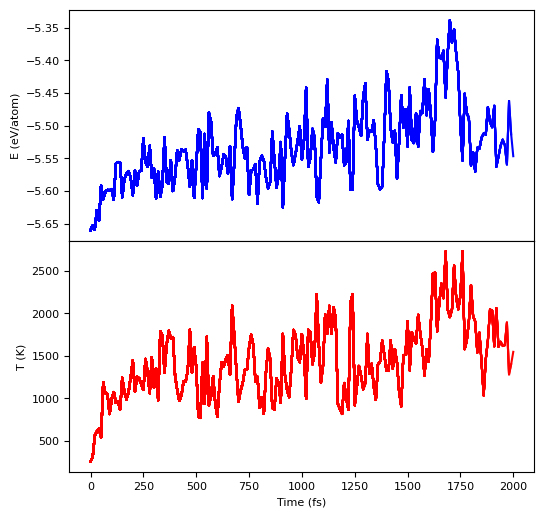

MD finished in 1.95 minutes!


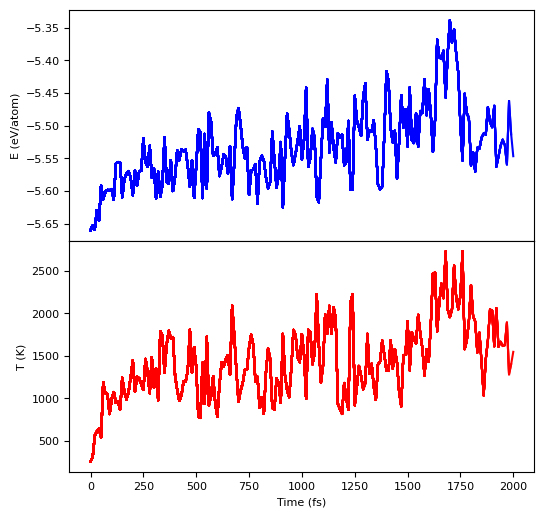

In [ ]:
from mace.calculators import mace_mp

macemp = mace_mp(model="small", device="cuda")
init_conf = ea.sel_by_info_val(read('data/solvent_molecs.xyz',':'), 'Nmols', 1)[0].copy()
simpleMD(init_conf, temp=1200, calc=macemp, fname='moldyn/mace03_md.xyz', s=10, T=2000)

OMG, look at that dynamics! Stable out-of-the-box, sign me up! Let's view the trajectory:

In [ ]:
from ase.io import read, write

traj = read('moldyn/mace03_md.xyz', ':')
view_x3d_n(traj)

### 3.2 Compare to XTB

Let's compute the radial distribution functions of this very stable trajectory and compare them to XTB. Remember MACE-MP was trained on PBE level of theory so we don't necessarily expect them to match:

In [ ]:
from matplotlib import pyplot as plt
from aseMolec import anaAtoms as aa

tag = 'OO_intra' #choose one of 'HH_intra', 'HC_intra', 'HO_intra', 'CC_intra', 'CO_intra', 'OO_intra'

for f in ['xtb_md', 'mace03_md']:
    traj = read('moldyn/'+f+'.xyz', '50:') #ignore first 50 frames
    for at in traj:
        at.pbc = True #create a fake box for rdf compatibility
        at.cell = [100,100,100]
    rdf = aa.compute_rdfs_traj_avg(traj, rmax=5, nbins=70) #aseMolec provides functionality to compute RDFs
    plt.plot(rdf[1], rdf[0][tag], '.-', label=f, alpha=0.7, linewidth=3)

plt.legend();
plt.yticks([]);
plt.xlabel(r'R ($\rm \AA$)');
plt.ylabel('RDF '+tag);

ImportError: Cannot import ase_ga.utilities.
The ase.ga code has moved to a separate project, ase_ga:
https://github.com/dtu-energy/ase-ga .
Please install it using e.g. pip install ase-ga.
Please import from ase_ga what would previously be imported from ase.ga.
ase.ga placeholders will be removed in a future release.


Notice there's a slight shift in the O-O RDF peak. This is likely due to the different level of reference theory. Can we fix by fine tuning MACE-MP-0?

Depending on your application, the PBE reference using in MACE-MP-0 may not be appropriate. It is probably better than XTB, but thats because for this notebook we are using XTB since it is extremely fast, so we can check the model's true error very easily.

In practice, you might want to run dynamics of this small molecule at the MP2 or coupled cluster level (which is the 'gold standard' of molecular quantum chemistry). In that case, you would want to finetune MACE-MP-0 onto a small amount of very expensive couple cluster data.

### 3.3 Fine tune MACE-MP to XTB

As described in the previous section, MACE-MP-0 offers qualitatively good performance across a wide range of chemistries and materials at the PBE+U level of theory.
However, for specific applications, it may be beneficial to fine-tune the model to improve its accuracy.
The fine-tuning process involves training a pre-trained model on a new dataset, called the fine-tuning dataset, which contains a limited amount of data that are only relevant to the specific application.

There exists two ways of finetuning a MACE mode: (1) ***standard*** approach which just restarts training using the parameters of the pretrained model (2) ***multi-head*** approach which ensures that the model does not forget too much about its pretraining.

We will start with the ***standard*** aproach below by setting `multiheads_finetuning: False` in the config. When finishing the training, you try to train another model with the ***multi-head*** approach and compare performances in MD. Remember to change the name both in the config and when running MD.

In [31]:
%%writefile config/config-07.yml

model: "MACE"
stress_weight: 0.0
forces_weight: 10.0
energy_weight: 1.0
foundation_model: "small"
multiheads_finetuning: False
name: "finetuned_MACE"
model_dir: "MACE_models"
log_dir: "MACE_models"
checkpoints_dir: "MACE_models"
results_dir: "MACE_models"
train_file: "data/solvent_xtb_train_50.xyz"
valid_fraction: 0.10
test_file: "data/solvent_xtb_test.xyz"
energy_key: "energy_xtb"
forces_key: "forces_xtb"
device: cpu
batch_size: 10
max_num_epochs: 500
num_samples_pt: 300
swa: True
seed: 345

Writing config/config-07.yml


In [32]:
train_mace("config/config-07.yml")

2026-07-13 00:31:53.177 INFO: ===========VERIFYING SETTINGS===========
2026-07-13 00:31:53.178 INFO: MACE version: 0.3.16
2026-07-13 00:31:53.178 INFO: Using CPU
2026-07-13 00:31:53.206 INFO: Using foundation model mace small as initial checkpoint.
Using Materials Project MACE for MACECalculator with /Users/Lilyes/.cache/mace/20231210mace128L0_energy_epoch249model
Using float64 for MACECalculator, which is slower but more accurate. Recommended for geometry optimization.
2026-07-13 00:31:53.248 INFO: Using CPU
2026-07-13 00:31:53.249 INFO: Using head Default out of  ['Default']
2026-07-13 00:31:53.249 INFO: ===========LOADING INPUT DATA===========
2026-07-13 00:31:53.249 INFO: Using heads: ['Default']
2026-07-13 00:31:53.250 INFO: Using the key specifications to parse data:
2026-07-13 00:31:53.250 INFO: Default: KeySpecification(info_keys={'energy': 'energy_xtb', 'stress': 'REF_stress', 'virials': 'REF_virials', 'dipole': 'dipole', 'head': 'head', 'elec_temp': 'elec_temp', 'total_charge

In [33]:
!wget https://github.com/ACEsuit/mace-foundations/releases/download/mace_mp_0b/mace_agnesi_small.model

--2026-07-13 01:17:44--  https://github.com/ACEsuit/mace-foundations/releases/download/mace_mp_0b/mace_agnesi_small.model
Resolving github.com (github.com)... 140.82.121.4
Connecting to github.com (github.com)|140.82.121.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/741903654/61b3510a-640b-4e4a-9c02-1991898dc394?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-07-13T00%3A05%3A25Z&rscd=attachment%3B+filename%3Dmace_agnesi_small.model&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-07-12T23%3A05%3A23Z&ske=2026-07-13T00%3A05%3A25Z&sks=b&skv=2018-11-09&sig=2uqSWCwzgABEntZWSsDbqY7F4lieAQ9XLO4Bj5RKezo%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc4MzkwMDA2NCwibmJmIjoxNzgzODk4MjY0LCJwYXRoIjoicmVsZWFzZ

Compare the final accuracy to the models trained from scratch. You should see that the errors are much better when doing finetuning.

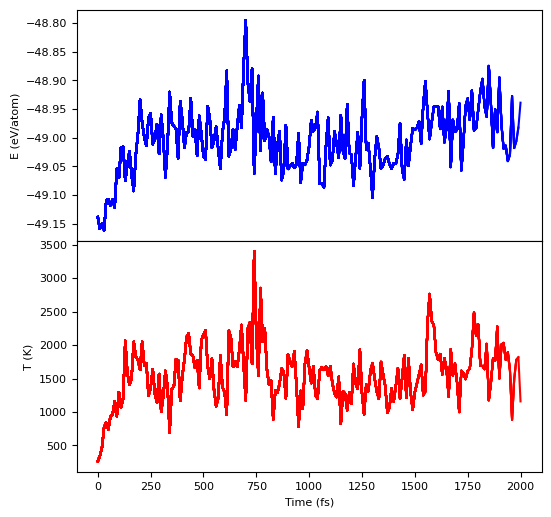

MD finished in 3.00 minutes!


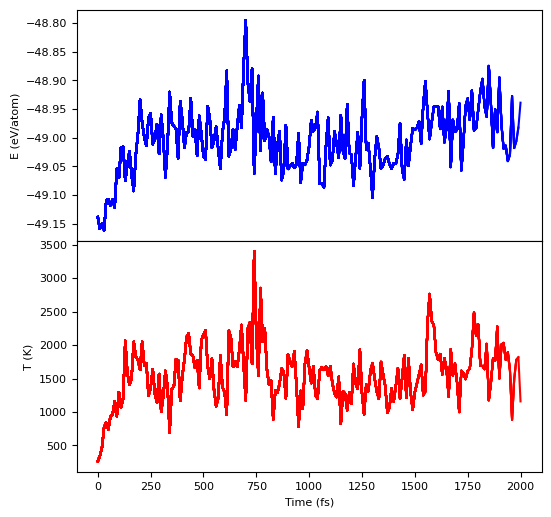

In [34]:
mace_calc = MACECalculator(model_paths=['MACE_models/finetuned_MACE_run-345_stagetwo.model'], device='cpu')

init_conf = ea.sel_by_info_val(read('data/solvent_molecs.xyz',':'), 'Nmols', 1)[0].copy()
simpleMD(init_conf, temp=1200, calc=mace_calc, fname='moldyn/mace_finetuned_md.xyz', s=10, T=2000)

In [35]:
!ls moldyn/


mace01_md.xyz           mace02_md_committee.xyz mace_finetuned_md.xyz
mace01_md_liquid.xyz    mace02_md_gen1.xyz      xtb_md.xyz
mace02_md.xyz           mace03_md.xyz


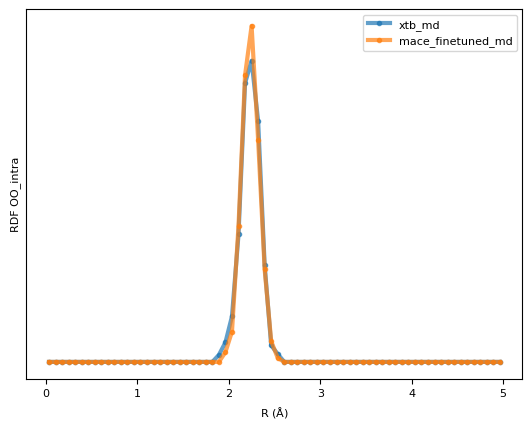

In [36]:
from matplotlib import pyplot as plt
from aseMolec import anaAtoms as aa

tag = 'OO_intra' # 'OO_intra' #choose one of 'HH_intra', 'HC_intra', 'HO_intra', 'CC_intra', 'CO_intra', 'OO_intra'

for f in ['xtb_md', 'mace_finetuned_md']:
    traj = read('moldyn/'+f+'.xyz', '50:') #ignore first 50 frames
    for at in traj:
        at.pbc = True #create a fake box for rdf compatibility
        at.cell = [100,100,100]
    rdf = aa.compute_rdfs_traj_avg(traj, rmax=5, nbins=70) #aseMolec provides functionality to compute RDFs
    plt.plot(rdf[1], rdf[0][tag], '.-', label=f, alpha=0.7, linewidth=3)

plt.legend();
plt.yticks([]);
plt.xlabel(r'R ($\rm \AA$)');
plt.ylabel('RDF '+tag);

In [37]:
from ase.io import read, write
import nglview as nv

traj = read('moldyn/mace_finetuned_md.xyz', ':')
view_x3d_n(traj)

What are the results - does it work?

Consider comparing more than one of the rdfs, and looking at how the MP0-model did (as we saw above) vs the finetuned version.